In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [12]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
X=pd.get_dummies(df.drop('median_house_value',axis=1),columns=['ocean_proximity'])
y_reg=df['median_house_value']


In [25]:


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [26]:
scaler = StandardScaler()

# Regression
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)


In [27]:
knn_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)

# Train
knn_reg.fit(X_train_reg_scaled, y_train_reg)

# Predict
y_pred_reg = knn_reg.predict(X_test_reg_scaled)

# Evaluate
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("KNN Regression Results:")
print("RMSE:", rmse)
print("R2 Score:", r2)


KNN Regression Results:
RMSE: 60921.72672694117
R2 Score: 0.7167711112316723


In [30]:
y_class = pd.cut(
    df['median_house_value'],
    bins=[0, 100000, 250000, np.inf],
    labels=[0, 1, 2]  # 0 = low, 1 = medium, 2 = high
)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

In [31]:
knn_clf = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

# Train
knn_clf.fit(X_train_clf_scaled, y_train_clf)

# Predict
y_pred_clf = knn_clf.predict(X_test_clf_scaled)

# Evaluate
acc = accuracy_score(y_test_clf, y_pred_clf)
print("KNN Classification Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_clf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_clf))


KNN Classification Accuracy: 0.782703488372093

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.70      0.73       732
           1       0.78      0.84      0.81      2240
           2       0.80      0.72      0.76      1156

    accuracy                           0.78      4128
   macro avg       0.78      0.75      0.77      4128
weighted avg       0.78      0.78      0.78      4128


Confusion Matrix:
 [[ 514  214    4]
 [ 152 1882  206]
 [   1  320  835]]


Text(0.5, 1.0, 'Correlation Heatmap')

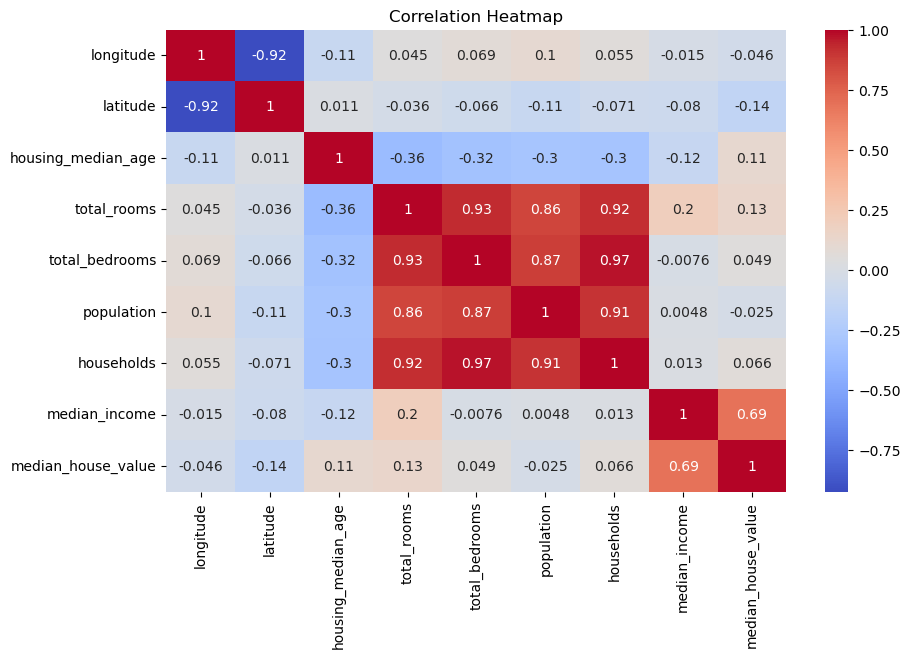

In [32]:
plt.figure(figsize = (10,6))
sns.heatmap((df.drop(['ocean_proximity'],axis =1)).corr(),annot=True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')